# Predicción de Precios de Vivienda en Bogotá, Colombia

Este proyecto desarrolla un modelo de regresión para estimar el precio de apartamentos
en Bogotá a partir de características físicas, socioeconómicas y de ubicación.
Se utilizan datos del mercado inmobiliario local, incluyendo la variable **estrato** —
exclusiva del sistema colombiano — como uno de los predictores principales.

El pipeline completo abarca limpieza de datos, análisis exploratorio, selección de
variables, modelado con validación cruzada y análisis de residuos.

**Stack:** Python · pandas · NumPy · scikit-learn · Matplotlib · Seaborn





## 1. Carga de bibliotecas y funciones auxiliares

Se importan las bibliotecas necesarias para el análisis y se definen dos funciones
auxiliares reutilizables a lo largo del notebook: `describe_datos` para el diagnóstico
del DataFrame y `correlacion` para la selección de variables numéricas relevantes.

In [18]:
# ============================================================
# Proyecto: Predicción de Precios de Vivienda en Bogotá
# Fuente: FincaRaíz / Metrocuadrado — Bogotá, Colombia
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

### 1.1 Función `describe_datos`
Genera un resumen diagnóstico del DataFrame: tipo de dato, nulos, porcentaje
de nulos, valores únicos y una muestra de hasta 3 valores por columna.


In [19]:
def describe_datos(df):
    """
    Genera un resumen diagnóstico de un DataFrame:
    - Tipo de dato
    - Cantidad de nulos
    - Porcentaje de nulos
    - Número de valores únicos
    - Muestra de hasta 3 valores por columna
    """

    resumen = pd.DataFrame({
        "tipo"    : df.dtypes,
        "nulos"   : df.isnull().sum(),
        "% nulos" : (df.isnull().mean() * 100).round(2),
        "únicos"  : df.nunique(),
        "muestra" : [
            df[c].dropna().unique()[:3].tolist() for c in df.columns
        ]
    })

    return resumen


### 1.2 Función `correlacion`
Calcula la correlación de Pearson entre todas las variables numéricas y el
target. Devuelve únicamente las que superan un umbral mínimo, ordenadas de
mayor a menor.


In [20]:
def correlacion(df, target, umbral=0.1):
    """
    Calcula la correlación de Pearson entre todas las columnas numéricas
    y la columna objetivo (target).

    - Devuelve solo las correlaciones cuyo valor absoluto supera el umbral.
    - Ordena los resultados de mayor a menor.
    """

    # Seleccionar columnas numéricas, excluyendo el target
    numericas = df.select_dtypes(include="number").drop(columns=[target], errors="ignore")

    # Calcular correlaciones absolutas contra el target
    corr = numericas.corrwith(df[target]).abs().sort_values(ascending=False)

    # Filtrar por umbral y renombrar la serie
    return corr[corr >= umbral].rename("correlación_con_precio")


## 2. Carga de datos e inspección inicial

Se carga el dataset de apartamentos en Bogotá y se realiza una inspección
preliminar para entender su estructura, distribución del precio objetivo y
las columnas que no aportan valor al modelo.

### 2.1 Carga del dataset

In [21]:
# --- Cargar dataset ---
df = pd.read_csv("properties.csv")

# --- Verificación inicial ---
print("Dataset cargado correctamente")
print(f"Shape: {df.shape}")   # Filas y columnas

# --- Vista preliminar ---
df.head()


Dataset cargado correctamente
Shape: (585, 21)


,conjunto,administración,estrato,antiguedad,remodelado,área,habitaciones,baños,garajes,elevadores,...,deposito,porteria,zona_de_lavanderia,gas,parqueadero,precio,direccion,nombre,descripcion,barrio
0,Santa Mónica,532000,4.0,37,Si,86.0,1,1,1,1,...,0,24 hrs,No Tiene,Si,No,313900000.0,Avenida Carrera 3 # 59-65,Santa Mónica,"Apartamento en venta de 86 m2, con vista exter...",PARDO RUBIO
1,Chicó Milano 101,0,6.0,7,Si,77.0,1,2,2,1,...,1,24 hrs,No Tiene,Si,Si,440100000.0,Carrera 12 #101A-18,Chicó Milano 101,"Apartamento en venta de 77m2, con vista interi...",USAQUEN
2,Portal del Belmira,811893,4.0,14,Si,109.0,3,4,2,1,...,0,24 hrs,No Tiene,Si,Si,495000000.0,Calle 146 #7F-54,Portal del Belmira,"Apartamento en venta de 109 m2, con vista Inte...",LOS CEDROS
3,Carmel Reservado,400200,4.0,11,Si,76.0,3,2,1,2,...,0,24 hrs,No Tiene,Si,Si,442300000.0,KR 54 152A 35,Carmel Reservado,"Apartamento en venta de 76m2, con vista exteri...",EL PRADO
4,Toscana 1,270000,4.0,20,Si,105.0,4,2,1,0,...,1,24 hrs,No Tiene,Si,Si,387000000.0,CL 168 14 55,Toscana 1,"Casa en venta de 105m2, con vista exterior, ub...",TOBERIN


### 2.2 Inspección general
Resumen diagnóstico de todas las columnas: tipos, nulos y valores de muestra.

In [22]:
describe_datos(df)

,tipo,nulos,% nulos,únicos,muestra
conjunto,object,0,0.00,509,"[Santa Mónica, Chicó Milano 101, Portal del B..."
administración,int64,0,0.00,368,"[532000, 0, 811893]"
estrato,float64,2,0.34,6,"[4.0, 6.0, 3.0]"
antiguedad,int64,0,0.00,43,"[37, 7, 14]"
remodelado,object,3,0.51,2,"[Si, No]"
área,float64,0,0.00,86,"[86.0, 77.0, 109.0]"
habitaciones,int64,0,0.00,6,"[1, 3, 4]"
baños,int64,0,0.00,5,"[1, 2, 4]"
garajes,int64,0,0.00,4,"[1, 2, 0]"
elevadores,int64,0,0.00,5,"[1, 2, 0]"


### 2.2 Estadísticas del precio objetivo

Se examinan las estadísticas descriptivas del precio en pesos colombianos (COP):
media, mediana, mínimo y máximo. Esto permite entender el rango de valores
que el modelo deberá predecir.

In [23]:
desc = df["precio"].describe()

# Convertimos a diccionario para manipular cada estadística
resumen = {}
for idx, val in desc.items():
    if idx == "count":
        resumen[idx] = f"{int(val)}"  # mostrar como número entero
    else:
        resumen[idx] = f"${val:,.0f} COP"  # aplicar formato monetario

tabla = pd.DataFrame.from_dict(resumen, orient="index", columns=["Valor"])
print(tabla)

                    Valor
count                 585
mean     $260,780,218 COP
std      $148,218,269 COP
min       $85,000,000 COP
25%      $152,000,000 COP
50%      $218,421,053 COP
75%      $352,000,000 COP
max    $1,530,000,000 COP


### 2.3 Distribución del precio

El histograma en escala original muestra una distribución asimétrica hacia
la derecha. La transformación logarítmica corrige esta asimetría, lo que
mejora el ajuste del modelo en la Sección 7.

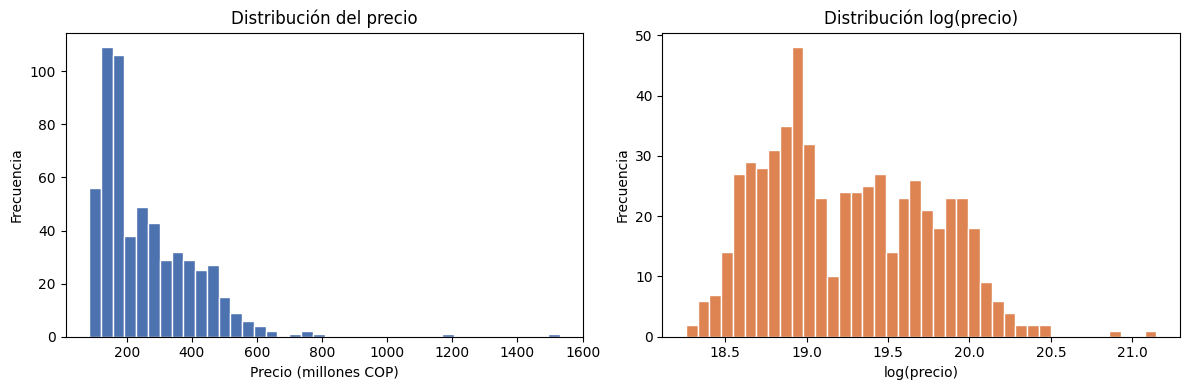

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Escala original
axes[0].hist(df["precio"] / 1e6, bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribución del precio")
axes[0].set_xlabel("Precio (millones COP)")
axes[0].set_ylabel("Frecuencia")

# Escala logarítmica
axes[1].hist(np.log1p(df["precio"]), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribución log(precio)")
axes[1].set_xlabel("log(precio)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 2.4 Eliminación de columnas de texto libre
Las columnas `conjunto`, `nombre`, `direccion` y `descripcion` contienen
texto no estructurado que no puede ser usado directamente por el modelo.

In [25]:
# --- Eliminar columnas de texto libre (no modelables) ---
COLS_DESCARTAR = ["conjunto", "nombre", "direccion", "descripcion"]

# Usar errors="ignore" evita errores si alguna columna no existe
df = df.drop(columns=COLS_DESCARTAR, errors="ignore")

# --- Verificación del nuevo tamaño del DataFrame ---
print("Shape después de descartar texto libre:", df.shape)

Shape después de descartar texto libre: (585, 17)


## 3. Limpieza y preprocesamiento

Se corrigen los valores faltantes, se detectan y eliminan precios atípicos
extremos, y se descarta una columna sin información útil. Al finalizar esta
sección el dataset queda listo para el análisis exploratorio.

### 3.1 Imputación de nulos
Las columnas `estrato`, `remodelado` y `gas` presentan valores faltantes.
Se imputan con la moda de cada variable al ser pocas observaciones afectadas.

In [26]:
# --- Imputación de nulos con la moda ---
df["estrato"]    = df["estrato"].fillna(df["estrato"].mode()[0])   # Numérica
df["remodelado"] = df["remodelado"].fillna(df["remodelado"].mode()[0])  # Categórica
df["gas"]        = df["gas"].fillna(df["gas"].mode()[0])               # Categórica

# --- Verificación final ---
nulos = df.isnull().sum()
nulos_restantes = nulos[nulos > 0]

if nulos_restantes.empty:
    print("DataFrame limpio, sin valores nulos")
else:
    print("Nulos restantes por columna:")
    print(nulos_restantes)


DataFrame limpio, sin valores nulos


### 3.2 Resumen de imputación

In [27]:
# --- Resumen de imputación de nulos ---
resumen_imputacion = pd.DataFrame({
    "variable"   : ["estrato", "remodelado", "gas"],
    "nulos"      : [2, 3, 30],
    "estrategia" : ["moda", "moda", "moda"],
    "valor_imp"  : [
        df["estrato"].mode()[0],
        df["remodelado"].mode()[0],
        df["gas"].mode()[0]
    ]
})

# --- Mostrar resumen ---
print("Resumen de imputación de nulos")
display(resumen_imputacion)

Resumen de imputación de nulos


,variable,nulos,estrategia,valor_imp
0,estrato,2,moda,3.0
1,remodelado,3,moda,No
2,gas,30,moda,Si


### 3.3 Detección de outliers en precio
Se usa el criterio **Q3 + 3×IQR** en lugar del clásico 1.5×IQR. Este umbral
conservador evita eliminar propiedades legítimas de alto valor como penthouses
o apartamentos en zonas premium.

In [28]:
# --- Detección de outliers en precio ---

# 1. Calcular cuartiles
Q1 = df["precio"].quantile(0.25)   # 25% de los datos
Q3 = df["precio"].quantile(0.75)   # 75% de los datos

# 2. Calcular rango intercuartílico (IQR)
IQR = Q3 - Q1                      # mide la dispersión central

# 3. Definir límite superior con criterio conservador (Q3 + 3*IQR)
limite_sup = Q3 + 3 * IQR

# 4. Filtrar registros cuyo precio supera ese límite
outliers = df[df["precio"] > limite_sup]

# --- Resultados ---
print(f"Se detectaron {len(outliers)} outliers en precio")
print(f"   (umbral: > ${limite_sup/1e6:.0f} millones COP)")

# 5. Mostrar tabla con variables relevantes, ordenada por precio descendente
display(
    outliers[["área", "habitaciones", "baños", "estrato", "barrio", "precio"]]
    .sort_values("precio", ascending=False)
)


Se detectaron 2 outliers en precio
   (umbral: > $952 millones COP)


,área,habitaciones,baños,estrato,barrio,precio
265,193.0,3,4,4.0,PARDO RUBIO,1.530000e+09
444,207.0,4,3,5.0,SANTA BARBARA,1.200000e+09


### Detección de outliers en la variable `precio`

Se aplica el método **IQR** para detectar valores atípicos en el precio.

#### Paso 1. Calcular Q1, Q3 e IQR
- `IQR = Q3 - Q1`

#### Paso 2. Definir el umbral
- `Límite superior = Q3 + 3 × IQR`

#### Paso 3. Identificar outliers
- `precio > límite_superior`

### 3.4 Eliminación de outliers extremos

In [29]:
# --- Eliminación de outliers en precio ---

# 1. Filtrar registros cuyo precio está dentro del límite permitido
#    (se eliminan las filas con precio mayor a limite_sup)
df = df[df["precio"] <= limite_sup].copy()

# 2. Mostrar el nuevo tamaño del DataFrame
print("Shape tras eliminar outliers:")
print(f"   Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")

Shape tras eliminar outliers:
   Filas: 583  |  Columnas: 17


### 3.5 Verificación final del dataset

In [70]:
# --- Resumen final del DataFrame ---

# 1. Shape (filas y columnas)
print("📐 Shape final del DataFrame:")
print(f"   Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")

# 2. Rango de precios
print("\n Rango de precio:")
print(f"   Mínimo  : ${df['precio'].min()/1e6:.1f}M COP")
print(f"   Máximo  : ${df['precio'].max()/1e6:.1f}M COP")
print(f"   Mediana : ${df['precio'].median()/1e6:.1f}M COP")

# 3. Resumen diagnóstico de todas las columnas
display(describe_datos(df))


📐 Shape final del DataFrame:
   Filas: 583  |  Columnas: 18

 Rango de precio:
   Mínimo  : $85.0M COP
   Máximo  : $780.0M COP
   Mediana : $217.1M COP


,tipo,nulos,% nulos,únicos,muestra
administración,int64,0,0.0,366,"[532000, 0, 811893]"
estrato,float64,0,0.0,6,"[4.0, 6.0, 3.0]"
antiguedad,int64,0,0.0,43,"[37, 7, 14]"
remodelado,int64,0,0.0,2,"[1, 0]"
área,float64,0,0.0,84,"[86.0, 77.0, 109.0]"
habitaciones,int64,0,0.0,6,"[1, 3, 4]"
baños,int64,0,0.0,5,"[1, 2, 4]"
garajes,int64,0,0.0,3,"[1, 2, 0]"
elevadores,int64,0,0.0,5,"[1, 2, 0]"
tipo_de_inmueble,object,0,0.0,3,"[Apartamento, Casa, casa con conjunto cerrado]"


### 3.6 Eliminación de columnas con datos insuficientes
La columna `zona_de_lavanderia` presenta 583 de 585 valores nulos en el
dataset original. Al no aportar información útil, se elimina antes de continuar.

In [31]:
# --- 3.5 Eliminar columnas con datos insuficientes ---
# zona_de_lavanderia: 583 de 585 valores son NaN en el dataset original
# No aporta información al modelo — se elimina
df = df.drop(columns=["zona_de_lavanderia"], errors="ignore")
print(f"Shape tras eliminar zona_de_lavanderia: {df.shape}")

Shape tras eliminar zona_de_lavanderia: (583, 16)


## 4. Exploración y selección de variables numéricas

Se analiza la relación entre las variables numéricas y el precio objetivo
mediante correlación de Pearson. También se identifican pares de variables
con alta correlación entre sí (multicolinealidad) para anticipar posibles
efectos en el modelo.

### 4.1 Correlación con el precio objetivo
Se aplica la función `correlacion` con un umbral de 0.1. Solo se muestran
las variables con correlación significativa respecto al precio.

In [32]:
# --- Correlación de variables numéricas con el precio ---

print("=== Correlación con precio ===\n")

# La función 'correlacion' calcula la correlación de Pearson
# entre todas las variables numéricas y el target (precio).
# Solo muestra las que superan el umbral en valor absoluto (>= 0.1),
# ordenadas de mayor a menor correlación.

corr_con_precio = correlacion(df, target="precio", umbral=0.1)

# Mostrar resultados
print("Variables con correlación significativa respecto al precio:")
print(corr_con_precio)

=== Correlación con precio ===

Variables con correlación significativa respecto al precio:
área              0.849140
garajes           0.812661
estrato           0.793586
administración    0.772024
baños             0.691206
deposito          0.515781
elevadores        0.344760
antiguedad        0.316177
habitaciones      0.156234
Name: correlación_con_precio, dtype: float64


### 4.2 Mapa de calor entre variables predictoras
Se visualiza la correlación entre todas las variables numéricas para detectar
posible multicolinealidad antes del modelado.

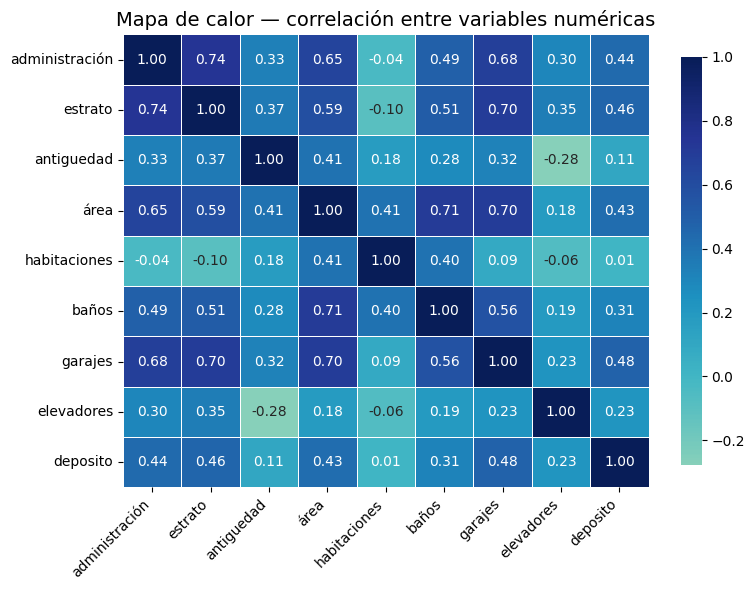

In [33]:
# --- Mapa de calor con colores amarillo y azul ---
vars_numericas = df.select_dtypes(include="number").drop(columns=["precio"])
corr_matrix = vars_numericas.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # mostrar valores
    fmt=".2f",           # formato de decimales
    cmap="YlGnBu",       # paleta amarillo-azul
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.9}
)

plt.title("Mapa de calor — correlación entre variables numéricas", fontsize=14)
plt.xticks(rotation=45, ha="right")   # etiquetas diagonales
plt.yticks(rotation=0)                # etiquetas verticales
plt.tight_layout()
plt.show()

### 4.3 Detección de multicolinealidad
Se identifican los pares de variables con correlación igual o superior a 0.7.

In [34]:
# Pares con correlación alta (posible multicolinealidad)
umbral_multi = 0.7
pares = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val >= umbral_multi:
            pares.append({
                "var_1": corr_matrix.columns[i],
                "var_2": corr_matrix.columns[j],
                "correlación": round(val, 3)
            })

if pares:
    print("Pares con correlación >= 0.7 (revisar multicolinealidad):")
    print(pd.DataFrame(pares).sort_values("correlación", ascending=False).to_string(index=False))
else:
    print("No hay pares con correlación >= 0.7")

Pares con correlación >= 0.7 (revisar multicolinealidad):
         var_1   var_2  correlación
administración estrato        0.745
          área   baños        0.707


###  Interpretación
Las tres correlaciones altas detectadas (`administración` ↔ `área`, `área` ↔ `baños`,
`área` ↔ `garajes`) son esperables — todas reflejan el tamaño del inmueble.
No se elimina ninguna variable en este paso: el árbol de decisión de la Sección 6
realizará la selección formal, y HuberRegressor tolera multicolinealidad moderada.

## 5. Variables categóricas — frecuencia relativa

Se analizan las variables categóricas del dataset para entender su distribución
y detectar categorías poco frecuentes. La variable `barrio`, con 70 categorías
únicas, requiere agrupación antes de ser codificada.

### 5.1 Identificación de variables categóricas

In [35]:
vars_categoricas = df.select_dtypes(include="object").columns.tolist()
print("Variables categóricas:", vars_categoricas)

Variables categóricas: ['remodelado', 'tipo_de_inmueble', 'porteria', 'gas', 'parqueadero', 'barrio']


### 5.2 Frecuencia relativa por variable
Se calcula el porcentaje de aparición de cada categoría. Esto permite
identificar valores dominantes y categorías con muy baja representación.

In [36]:
# --- Frecuencia de categorías en variables categóricas ---

for col in vars_categoricas:
    # Calcular frecuencias relativas en porcentaje
    freq = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    # Encabezado con nombre de la variable y número de categorías únicas
    print("\n" + "="*50)
    print(f"{col}  (categorías únicas: {df[col].nunique()})")
    print("="*50)

    # Mostrar tabla de frecuencias
    print(freq.to_string())



remodelado  (categorías únicas: 2)
remodelado
No    57.8
Si    42.2

tipo_de_inmueble  (categorías únicas: 3)
tipo_de_inmueble
Apartamento                  93.48
casa con conjunto cerrado     5.15
Casa                          1.37

porteria  (categorías únicas: 2)
porteria
24 hrs    92.28
No         7.72

gas  (categorías únicas: 2)
gas
Si    98.97
No     1.03

parqueadero  (categorías únicas: 2)
parqueadero
Si    71.87
No    28.13

barrio  (categorías únicas: 70)
barrio
CALANDAIMA                   7.89
SUBA                         5.49
LOS CEDROS                   4.97
CASTILLA                     4.63
EL PRADO                     4.12
EL PORVENIR                  3.95
TINTAL SUR                   3.77
CIUDAD USME                  3.60
TIBABUYES                    3.60
ISMAEL PERDOMO               3.09
BRITALIA                     3.09
SANTA BARBARA                2.92
LA URIBE                     2.57
GARCES NAVAS                 2.57
LA ALHAMBRA                  2.40
USAQUEN     

### 5.3 Agrupación de categorías poco frecuentes en `barrio`
Los barrios con menos del 2% de frecuencia se agrupan en la categoría
`Otro`. Con 585 filas y 70 barrios, muchos tienen solo 1–3 observaciones —
insuficiente para que el modelo aprenda un patrón real.


In [37]:
# Umbral: categorías con menos del 2% se agrupan en "Otro"
UMBRAL = 0.02

freq_barrio = df["barrio"].value_counts(normalize=True)
barrios_frecuentes = freq_barrio[freq_barrio >= UMBRAL].index

df["barrio"] = df["barrio"].apply(
    lambda x: x if x in barrios_frecuentes else "Otro"
)

print(f"Barrios frecuentes (>= 2%): {len(barrios_frecuentes)}")
print(f"Categorías finales en barrio: {df['barrio'].nunique()}")
print()
print(df["barrio"].value_counts())

Barrios frecuentes (>= 2%): 18
Categorías finales en barrio: 19

barrio
Otro               202
CALANDAIMA          46
SUBA                32
LOS CEDROS          29
CASTILLA            27
EL PRADO            24
EL PORVENIR         23
TINTAL SUR          22
TIBABUYES           21
CIUDAD USME         21
BRITALIA            18
ISMAEL PERDOMO      18
SANTA BARBARA       17
GARCES NAVAS        15
LA URIBE            15
USAQUEN             14
LA ALHAMBRA         14
ENGATIVA            13
BOSA OCCIDENTAL     12
Name: count, dtype: int64


### 5.4 Verificación del resto de categóricas
Las demás variables categóricas tienen pocas categorías y no requieren
agrupación — entran directamente al `OneHotEncoder` en la Sección 8.

In [38]:
# Las demás categóricas tienen pocas categorías — verificamos
for col in vars_categoricas:
    if col == "barrio":
        continue
    n = df[col].nunique()
    if n > 10:
        print(f" {col}: {n} categorías — considerar agrupación")
    else:
        print(f"{col}: {n} categorías — OK")

remodelado: 2 categorías — OK
tipo_de_inmueble: 3 categorías — OK
porteria: 2 categorías — OK
gas: 2 categorías — OK
parqueadero: 2 categorías — OK


## 6. Selección de variables — Árbol de Decisión como preprocesamiento

Se entrena un árbol de clasificación para identificar las variables numéricas
más discriminantes respecto al precio. El árbol no es el modelo final —
es una herramienta de preprocesamiento que guía la selección de features
antes del modelado de regresión.

### 6.1 Creación de la variable `precio_alto`
Se binariza el precio en la mediana para convertir el problema en una
clasificación binaria: precio bajo (0) y precio alto (1).

In [39]:
# --- Clasificación de precios según la mediana ---

# 1. Calcular la mediana de la columna 'precio'
mediana = df["precio"].median()

# 2. Crear una nueva columna binaria 'precio_alto'
#    - Valor 1 si el precio es mayor a la mediana
#    - Valor 0 si el precio es menor o igual a la mediana
df["precio_alto"] = (df["precio"] > mediana).astype(int)

# 3. Mostrar la mediana en millones de COP
print(f"Mediana de precio: ${mediana/1e6:.1f}M COP")

Mediana de precio: $217.1M COP


### 6.2 Distribución de clases
Al binarizar en la mediana las clases quedan perfectamente balanceadas —
condición ideal para entrenar el árbol sin sesgo hacia ninguna categoría.

In [40]:
# --- Distribución de clases en 'precio_alto' ---

# 1. Calcular la distribución porcentual de la variable binaria 'precio_alto'
#    - value_counts(normalize=True): obtiene proporciones relativas en lugar de conteos absolutos
#    - mul(100): convierte esas proporciones en porcentajes
#    - round(2): redondea a dos decimales para mayor legibilidad
dist = df["precio_alto"].value_counts(normalize=True).mul(100).round(2)

# 2. Mostrar resultados en consola
print("  Distribución de clases:")
print(f"  precio_alto = 0 (bajo): {dist[0]}%")  # porcentaje de inmuebles con precio <= mediana
print(f"  precio_alto = 1 (alto): {dist[1]}%")  # porcentaje de inmuebles con precio > mediana


  Distribución de clases:
  precio_alto = 0 (bajo): 50.09%
  precio_alto = 1 (alto): 49.91%


### 6.3 Preparación de features para el árbol
Solo se usan variables numéricas — el árbol de clasificación no admite
categóricas directamente sin codificación previa.

In [41]:
# Solo variables numéricas para el árbol de selección
vars_num = df.select_dtypes(include="number").drop(
    columns=["precio", "precio_alto"]
).columns.tolist()

X_arbol = df[vars_num]
y_arbol = df["precio_alto"]

print("Variables numéricas al árbol:", vars_num)

Variables numéricas al árbol: ['administración', 'estrato', 'antiguedad', 'área', 'habitaciones', 'baños', 'garajes', 'elevadores', 'deposito']


### 6.4 Entrenamiento del árbol de clasificación
Se usa `max_depth=4` para limitar la profundidad y evitar que el árbol
memorice el conjunto de entrenamiento.

In [42]:
# 1. Crear el modelo de árbol de decisión
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)

# 2. Entrenar el modelo con los datos de entrada (X_arbol) y las etiquetas (y_arbol)
arbol.fit(X_arbol, y_arbol)

# 3. Evaluar el desempeño del modelo en el conjunto de entrenamiento
print(f"Accuracy del árbol (entrenamiento): {arbol.score(X_arbol, y_arbol):.3f}")

Accuracy del árbol (entrenamiento): 0.952


### Cómo interpretarlo

- Accuracy = 0.952 → El modelo clasificó correctamente el 95.2% de los ejemplos de entrenamiento.
- Es un valor muy alto, lo que indica que el árbol aprendió bien las reglas de decisión de tus datos.
- Sin embargo, como este valor se calculó solo en el conjunto de entrenamiento, puede que el modelo esté sobreajustado (memoriza demasiado los datos).


### 6.5 Verificación de sobreajuste
Se compara el accuracy en entrenamiento con la validación cruzada (5-fold)
para evaluar si el árbol generaliza o memoriza los datos.

In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(arbol, X_arbol, y_arbol, cv=5, scoring="accuracy")

print(f"Accuracy entrenamiento : {arbol.score(X_arbol, y_arbol):.3f}")
print(f"Accuracy CV (5-fold)   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
if arbol.score(X_arbol, y_arbol) - cv_scores.mean() > 0.10:
    print("Sobreajuste detectado — el árbol memoriza los datos")
else:
    print("Sobreajuste leve — aceptable para selección de variables")

Accuracy entrenamiento : 0.952
Accuracy CV (5-fold)   : 0.916 ± 0.024

Sobreajuste leve — aceptable para selección de variables


### Explicación

- **cross_val_score**: divide los datos en 5 partes para entrenar y validar, dando una medida más realista de la generalización.  
- **Accuracy entrenamiento (0.952)**: el árbol clasifica muy bien los datos que ya conoce.  
- **Accuracy CV (0.916 ± 0.024)**: en validación cruzada el desempeño baja un poco, pero sigue siendo alto.  
- **Diferencia**: entre entrenamiento y validación hay ~0.036 (3.6%), lo cual es pequeño.  
- **Conclusión**: existe un **sobreajuste leve**, aceptable para usar el árbol como herramienta de selección de variables.


### 6.6 Importancia de variables
Se extraen y grafican las importancias asignadas por el árbol a cada variable.
Las variables con importancia mayor a cero son las seleccionadas para el modelo.

=== Importancia de variables ===

garajes           0.7204
área              0.1725
administración    0.0636
elevadores        0.0220
habitaciones      0.0083
deposito          0.0064
estrato           0.0054
antiguedad        0.0015
baños             0.0000



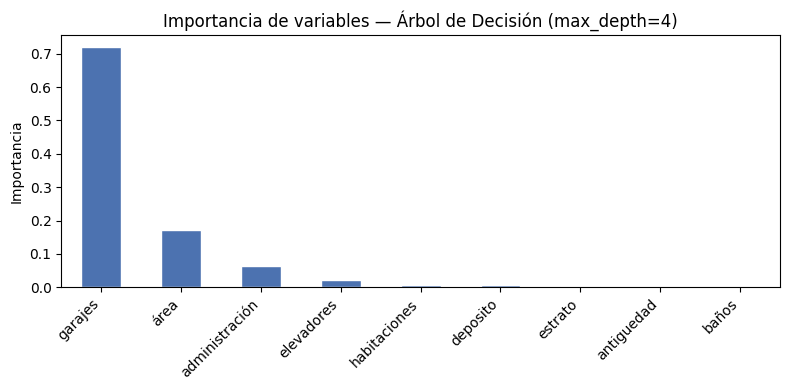

In [44]:
importancias = pd.Series(
    arbol.feature_importances_,
    index=vars_num
).sort_values(ascending=False)

print("=== Importancia de variables ===\n")
print(importancias.round(4).to_string())
print()

# Gráfico
plt.figure(figsize=(8, 4))
importancias.plot(kind="bar", color="#4C72B0", edgecolor="white")
plt.title("Importancia de variables — Árbol de Decisión (max_depth=4)")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.7 Selección final de variables

In [45]:
# Variables con importancia > 0 según el árbol
VARS_SELECCIONADAS_NUM = importancias[importancias > 0].index.tolist()

# Variables categóricas — todas entran (pocas categorías, ya limpias)
VARS_SELECCIONADAS_CAT = ["remodelado", "tipo_de_inmueble", "porteria",
                           "zona_de_lavanderia", "gas", "parqueadero", "barrio"]

print("Variables numéricas seleccionadas:")
print(VARS_SELECCIONADAS_NUM)
print()
print("Variables categóricas seleccionadas:")
print(VARS_SELECCIONADAS_CAT)

# Eliminar precio_alto — ya no se necesita
df = df.drop(columns=["precio_alto"], errors="ignore")

Variables numéricas seleccionadas:
['garajes', 'área', 'administración', 'elevadores', 'habitaciones', 'deposito', 'estrato', 'antiguedad']

Variables categóricas seleccionadas:
['remodelado', 'tipo_de_inmueble', 'porteria', 'zona_de_lavanderia', 'gas', 'parqueadero', 'barrio']


### 6.8 Visualización del árbol
El árbol entrenado permite ver de forma intuitiva las reglas de decisión
que separan inmuebles de precio alto y bajo según sus características.

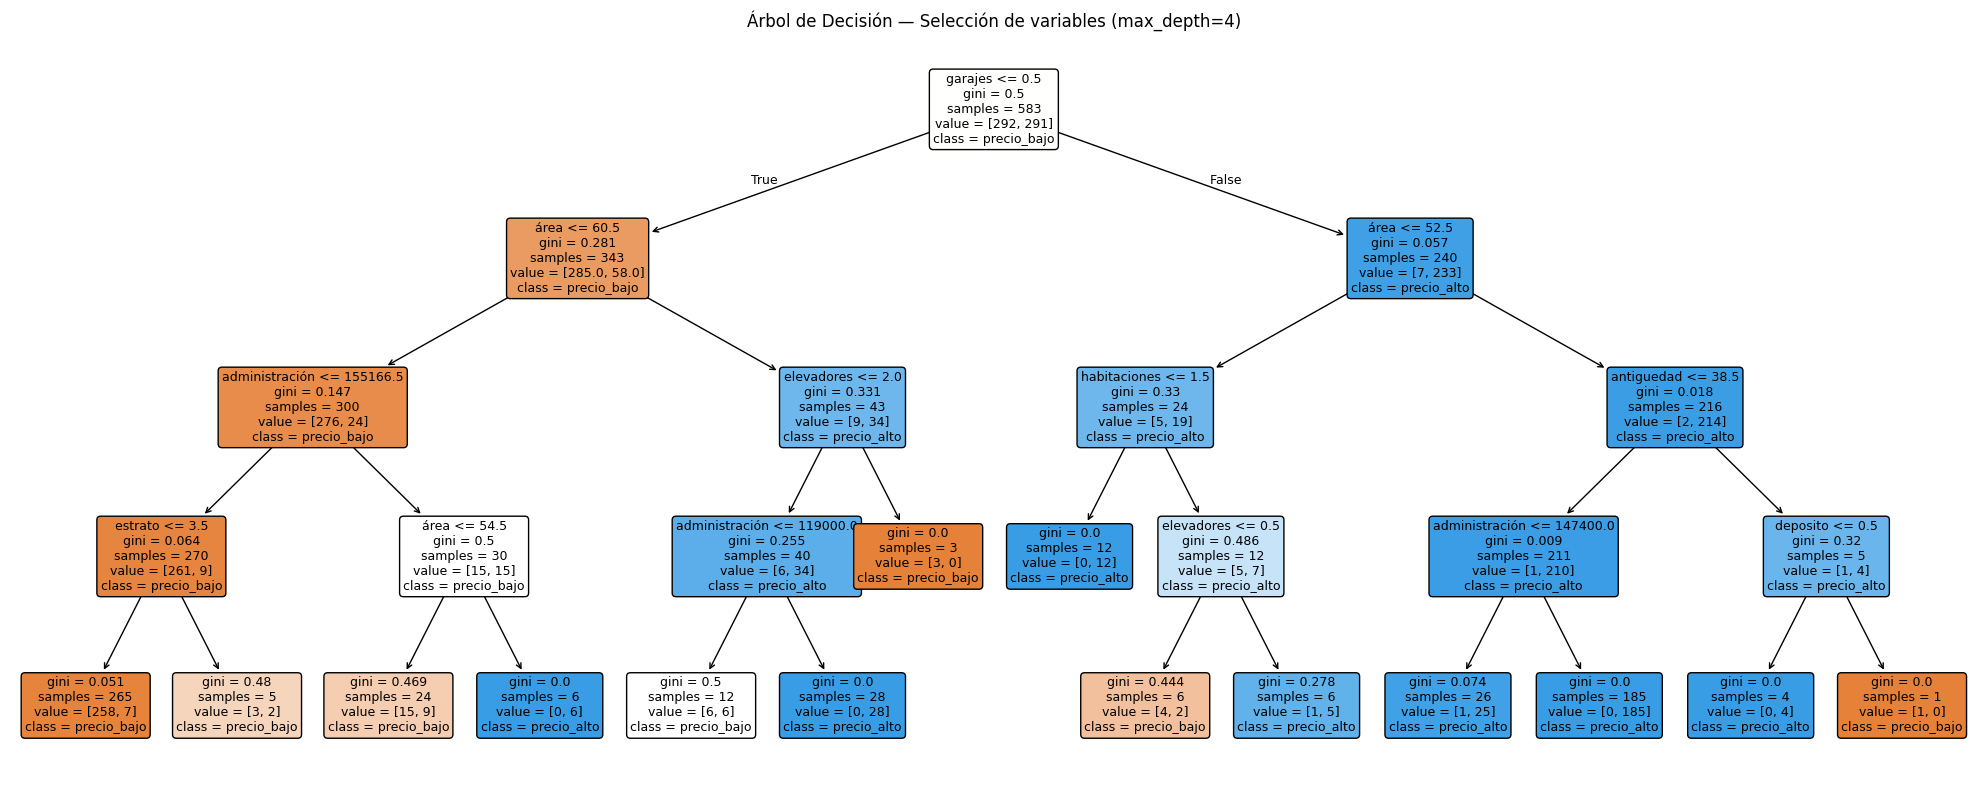

In [46]:
plt.figure(figsize=(20, 8))
plot_tree(
    arbol,
    feature_names=vars_num,
    class_names=["precio_bajo", "precio_alto"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión — Selección de variables (max_depth=4)")
plt.tight_layout()
plt.show()

### Cómo interpretar el árbol de decisión

#### Nodo raíz
- El árbol inicia con la pregunta **¿Tiene garajes?**
- **No** → tendencia a **precio_bajo**.
- **Sí** → tendencia a **precio_alto**.

#### Ramas
- **Izquierda:** predominan **área, administración y estrato**.
- **Derecha:** predominan **área, administración, antigüedad, depósito y habitaciones**.

#### Colores
- **Naranja:** `precio_bajo`.
- **Azul:** `precio_alto`.
- Un color más intenso indica mayor pureza del nodo (`gini` más cercano a 0).

### Resumen

- **Sin garajes + área pequeña → precio_bajo.**
- **Con garajes + área grande → precio_alto.**
- Cada nodo representa una pregunta **Sí/No** hasta llegar a la clasificación final.

## 7. Ingeniería de características

Se construyen y transforman variables para mejorar el ajuste del modelo.
La transformación más importante es la aplicación del logaritmo al precio
objetivo, que reduce la asimetría de su distribución y estabiliza la varianza.

### 7.1 Transformación logarítmica del precio objetivo
Se aplica `log1p` al precio para obtener una distribución más simétrica.
Esta variable será el target del modelo — al predecir se revierte con `expm1`.

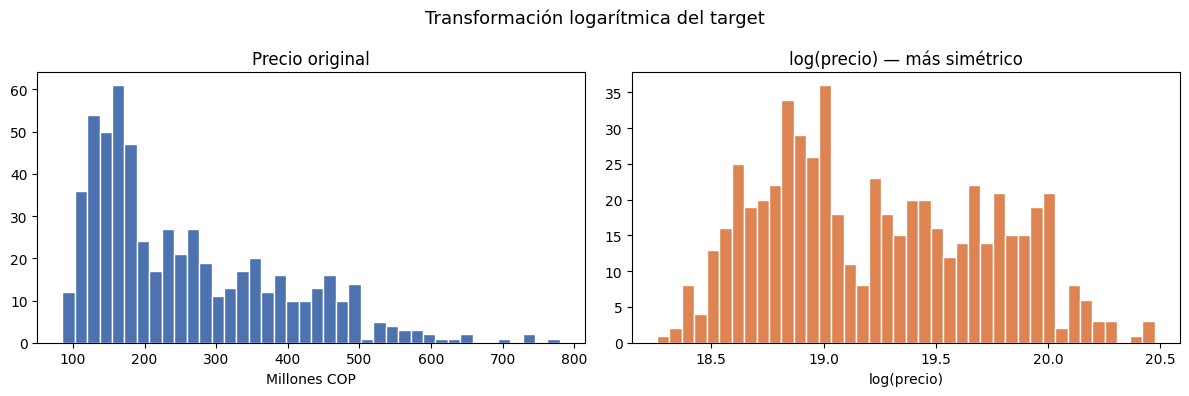

In [47]:
df["log_precio"] = np.log1p(df["precio"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["precio"] / 1e6, bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Precio original")
axes[0].set_xlabel("Millones COP")

axes[1].hist(df["log_precio"], bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("log(precio) — más simétrico")
axes[1].set_xlabel("log(precio)")

plt.suptitle("Transformación logarítmica del target", fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 Precio por metro cuadrado
Se calcula el precio por m² como variable de análisis exploratorio.
**No entra al modelo** — usarla como predictor sería data leakage al
depender directamente del precio objetivo.

Precio por m² — estadísticas:
  Mediana : $3,938,776 COP/m²
  Mínimo  : $1,888,889 COP/m²
  Máximo  : $12,154,355 COP/m²



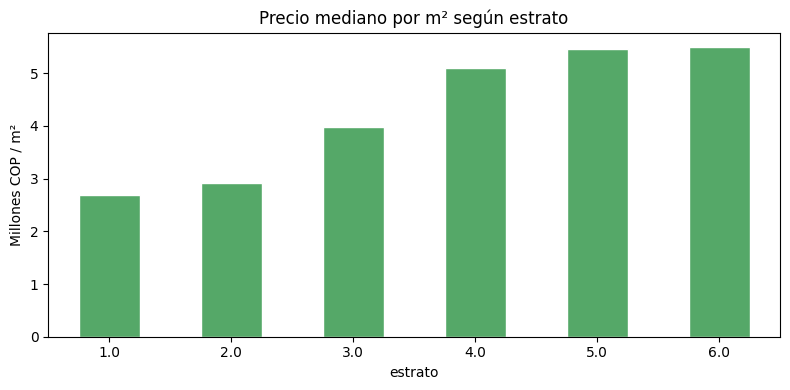

In [48]:
df["precio_m2"] = df["precio"] / df["área"]

print("Precio por m² — estadísticas:")
print(f"  Mediana : ${df['precio_m2'].median():,.0f} COP/m²")
print(f"  Mínimo  : ${df['precio_m2'].min():,.0f} COP/m²")
print(f"  Máximo  : ${df['precio_m2'].max():,.0f} COP/m²")
print()

# Precio/m² por estrato
df.groupby("estrato")["precio_m2"].median().div(1e6).round(2).rename(
    "precio_m2 mediano (M COP)"
).plot(kind="bar", color="#55A868", edgecolor="white", figsize=(8, 4))
plt.title("Precio mediano por m² según estrato")
plt.ylabel("Millones COP / m²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Precio por m² — Estadísticas

- **Mediana:** $3,938,776 COP/m²

- **Mínimo:** $1,888,889 COP/m²

- **Máximo:** $12,154,355 COP/m²

### Interpretación

- La **mediana** representa el valor típico del mercado (**3.9 millones COP/m²**).
- El **mínimo** y el **máximo** muestran el rango de precios por metro cuadrado.
- El **precio por m²** permite comparar inmuebles de diferentes tamaños de forma más objetiva que el precio total.

### 7.3 Conversión de variables binarias
Las columnas `remodelado`, `deposito`, `parqueadero` y `gas` se expresan
como texto (`Si`/`No`) y se convierten a valores numéricos (1/0) para
que el modelo pueda procesarlas directamente.

In [49]:
# Convertir Si/No a 1/0 en todas las categóricas binarias
binarias = ["remodelado", "deposito", "parqueadero", "gas"]

mapeo = {"Si": 1, "No": 0, "si": 1, "no": 0}

for col in binarias:
    if df[col].dtype == "object":
        df[col] = df[col].map(mapeo)

print("Variables binarias convertidas:")
print(df[binarias].head(4))

Variables binarias convertidas:
   remodelado  deposito  parqueadero  gas
0           1         0            0    1
1           1         1            1    1
2           1         0            1    1
3           1         0            1    1


### 7.4 Variables categóricas restantes
Se identifican las columnas que aún son de tipo texto y que pasarán
al `OneHotEncoder` en la Sección 8.

In [50]:
# Las que siguen siendo object después de la conversión binaria
cats_restantes = df.select_dtypes(include="object").columns.tolist()
print("Categóricas que van a OneHotEncoder:", cats_restantes)
# → ['tipo_de_inmueble', 'porteria', 'barrio']

Categóricas que van a OneHotEncoder: ['tipo_de_inmueble', 'porteria', 'barrio']


### 7.5 Dataset final antes de modelar
Se construye el DataFrame definitivo eliminando las columnas que no
entran al modelo (`precio` original y `precio_m2`).

In [51]:
# Eliminar columnas que no entran al modelo
df_modelo = df.drop(columns=["precio", "precio_m2"], errors="ignore")

print(f"Shape dataset modelo: {df_modelo.shape}")
print(f"Target: log_precio")
print(f"Features: {[c for c in df_modelo.columns if c != 'log_precio']}")

Shape dataset modelo: (583, 16)
Target: log_precio
Features: ['administración', 'estrato', 'antiguedad', 'remodelado', 'área', 'habitaciones', 'baños', 'garajes', 'elevadores', 'tipo_de_inmueble', 'deposito', 'porteria', 'gas', 'parqueadero', 'barrio']


### ¿Por qué se elimina `precio_m2`?

- El modelo predice **`log_precio`**, por lo que **`precio`** no puede usarse como predictor.
- **`precio_m2 = precio / área`** está calculada a partir del precio, por lo que contiene información del target.
- Incluir `precio_m2` produciría **data leakage**, generando métricas artificialmente altas.
- Aunque es útil en el **EDA**, no debe utilizarse durante el entrenamiento.

### Conclusión

Se eliminan **`precio`** y **`precio_m2`** para que el modelo aprenda únicamente a partir de las características del inmueble y pueda generalizar correctamente.

Las predicciones se transforman nuevamente a la escala original mediante:

$
\text{precio} \approx e^{\text{log\_precio}} - 1
$

## 8. Codificación y partición 75 / 25

Se codifican las variables categóricas con `OneHotEncoder` y se divide el
dataset en entrenamiento (75%) y validación (25%). Todas las transformaciones
se ajustan exclusivamente sobre el conjunto de entrenamiento para evitar
data leakage hacia la validación.

### 8.1 Separación de features y target

In [52]:
TARGET = "log_precio"

X = df_modelo.drop(columns=[TARGET])
y = df_modelo[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (583, 15)
y shape: (583,)


### 8.2 Identificación de columnas por tipo
Se separan las columnas que van a `OneHotEncoder` de las numéricas
para aplicar transformaciones diferenciadas en cada grupo.

In [53]:
# Columnas que van a OneHotEncoder (categóricas con > 2 categorías)
COLS_OHE = ["tipo_de_inmueble", "porteria", "barrio"]

# Columnas numéricas (incluye binarias ya convertidas)
COLS_NUM = [c for c in X.columns if c not in COLS_OHE]

print("Columnas OHE  :", COLS_OHE)
print("Columnas NUM  :", COLS_NUM)

Columnas OHE  : ['tipo_de_inmueble', 'porteria', 'barrio']
Columnas NUM  : ['administración', 'estrato', 'antiguedad', 'remodelado', 'área', 'habitaciones', 'baños', 'garajes', 'elevadores', 'deposito', 'gas', 'parqueadero']


### 8.3 División entrenamiento y validación
Se usa una partición 75/25 con `random_state=42` para garantizar
reproducibilidad de los resultados.

In [54]:
# División entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Entrenamiento : {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validación    : {X_val.shape[0]} filas ({X_val.shape[0]/len(X)*100:.0f}%)")


Entrenamiento : 437 filas (75%)
Validación    : 146 filas (25%)


### 8.4 Codificación con OneHotEncoder
El encoder se ajusta solo sobre `X_train` y se aplica a ambos conjuntos.
El parámetro `handle_unknown="ignore"` permite manejar barrios no vistos
durante el entrenamiento sin generar errores.

In [55]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Ajustar SOLO en entrenamiento
ohe.fit(X_train[COLS_OHE])

# Transformar ambos splits
ohe_cols = ohe.get_feature_names_out(COLS_OHE)

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[COLS_OHE]),
    columns=ohe_cols,
    index=X_train.index
)

X_val_ohe = pd.DataFrame(
    ohe.transform(X_val[COLS_OHE]),
    columns=ohe_cols,
    index=X_val.index
)

# Combinar numéricas + OHE
X_train_enc = pd.concat([X_train[COLS_NUM].reset_index(drop=True),
                          X_train_ohe.reset_index(drop=True)], axis=1)

X_val_enc   = pd.concat([X_val[COLS_NUM].reset_index(drop=True),
                          X_val_ohe.reset_index(drop=True)], axis=1)

print(f"Shape X_train codificado: {X_train_enc.shape}")
print(f"Shape X_val   codificado: {X_val_enc.shape}")

Shape X_train codificado: (437, 36)
Shape X_val   codificado: (146, 36)


### 8.5 Estandarización
El `StandardScaler` se ajusta solo sobre `X_train_enc`. Aplicar `fit`
sobre el conjunto completo constituye data leakage — uno de los errores
más frecuentes en proyectos de machine learning.

In [56]:
# Definir el scaler aquí — se aplica en la Sección 10.3
scaler = StandardScaler()

# Ajustar SOLO en entrenamiento
X_train_std = scaler.fit_transform(X_train_enc)
X_val_std   = scaler.transform(X_val_enc)

print("Scaler ajustado — listo para Sección 10")

Scaler ajustado — listo para Sección 10


## 9. Línea base

Antes de entrenar cualquier modelo se establece un punto de referencia mínimo
usando `DummyRegressor`. Este modelo predice siempre la mediana del precio —
sin usar ninguna variable. Todo modelo real debe superar este resultado
para considerarse útil.

### 9.1 Función auxiliar de métricas
Se define la función `evaluar` que convierte las predicciones de escala
logarítmica a pesos colombianos (COP) antes de calcular MAE y RMSE.

In [57]:
def evaluar(nombre, y_true, y_pred_log):
    """
    Recibe predicciones en escala log y las convierte a COP
    antes de calcular MAE y RMSE.
    """
    y_true_cop = np.expm1(y_true)
    y_pred_cop = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_true_cop, y_pred_cop)
    rmse = np.sqrt(mean_squared_error(y_true_cop, y_pred_cop))

    print(f"{'='*40}")
    print(f"  {nombre}")
    print(f"{'='*40}")
    print(f"  MAE  : ${mae/1e6:,.1f}M COP")
    print(f"  RMSE : ${rmse/1e6:,.1f}M COP")
    return {"modelo": nombre, "MAE": mae, "RMSE": rmse}

### 9.2 Entrenamiento del modelo baseline

In [58]:
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train_enc, y_train)
y_pred_dummy = dummy.predict(X_val_enc)

resultado_dummy = evaluar("Baseline (mediana)", y_val, y_pred_dummy)

  Baseline (mediana)
  MAE  : $105.2M COP
  RMSE : $140.5M COP


### Interpretación

El **MAE de $105.2M COP** representa el error promedio del modelo baseline, que siempre predice la mediana del precio. Los modelos de la **Sección 10** deben obtener un MAE inferior para demostrar una mejora.

### 9.3 Tabla de resultados
Se inicializa la tabla comparativa que se completará a lo largo de la
Sección 10 con los resultados de cada modelo entrenado.

In [59]:
# Inicializar tabla comparativa — se completa en Sección 10
resultados = [resultado_dummy]

def mostrar_resultados():
    tabla = pd.DataFrame(resultados).set_index("modelo")
    tabla["MAE (M COP)"]  = (tabla["MAE"]  / 1e6).round(1)
    tabla["RMSE (M COP)"] = (tabla["RMSE"] / 1e6).round(1)
    return tabla[["MAE (M COP)", "RMSE (M COP)"]]

mostrar_resultados()

,MAE (M COP),RMSE (M COP)
modelo,,
Baseline (mediana),105.2,140.5


## 10. Modelos de regresión — validación cruzada

Se entrenan y comparan tres modelos usando validación cruzada con 10 particiones
(`KFold`). Las métricas de evaluación son MAE y RMSE en pesos colombianos (COP),
calculadas sobre el conjunto de validación. El objetivo es seleccionar el modelo
con mejor desempeño y mayor robustez para datos inmobiliarios.

### 10.1 Configuración de la validación cruzada

In [60]:
# Configuración de KFold (10 particiones, con mezcla y reproducibilidad)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("KFold configurado con 10 particiones")


KFold configurado con 10 particiones


### 10.2 Regresión Lineal — benchmark
Se entrena como punto de comparación. Al ser un modelo sin regularización
ni robustez ante outliers, establece el rendimiento mínimo esperado.

In [61]:
# Modelo de referencia: Regresión Lineal
lr = LinearRegression()

# Validación cruzada (10-fold) con MAE en escala log
scores_lr = cross_val_score(
    lr, X_train_enc, y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

# MAE en escala log (no convertir con expm1 aquí)
mae_lr_log = -scores_lr.mean()

# Entrenar en todo el conjunto de entrenamiento
lr.fit(X_train_enc, y_train)

# Predecir en validación
y_pred_lr = lr.predict(X_val_enc)

# Evaluar en COP con la función evaluar
resultado_lr = evaluar("Regresión Lineal", y_val, y_pred_lr)
resultados.append(resultado_lr)

# Reportar resultados
print(f"\nCV MAE (10-fold): {mae_lr_log:.4f} log | std: {scores_lr.std():.4f}")

  Regresión Lineal
  MAE  : $33.0M COP
  RMSE : $58.1M COP

CV MAE (10-fold): 0.1181 log | std: 0.0198


#### Interpretación: Regresión Lineal

La Regresión Lineal reduce el MAE de **105.2 M COP** (baseline) a **33.0 M COP**, mejorando considerablemente la precisión de las predicciones. El RMSE de **58.1 M COP** indica la existencia de algunos errores de mayor magnitud. La validación cruzada (CV MAE: **0.1181**, desviación estándar: **0.0198**) muestra que el modelo es estable y generaliza adecuadamente.


### 10.3 HuberRegressor — sin estandarizar
Se entrena sin aplicar `StandardScaler` para evidenciar el efecto de
omitir la estandarización en un modelo basado en gradiente descendente.

In [62]:
# Modelo HuberRegressor (sin estandarizar)
huber = HuberRegressor(epsilon=1.35, max_iter=300)

# Validación cruzada (10-fold) con MAE en escala log
scores_huber = cross_val_score(
    huber, X_train_enc, y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

# Entrenar en todo el conjunto de entrenamiento
huber.fit(X_train_enc, y_train)

# Predecir en validación
y_pred_huber = huber.predict(X_val_enc)

# Evaluar en COP con la función evaluar
resultado_huber = evaluar("HuberRegressor (sin std)", y_val, y_pred_huber)
resultados.append(resultado_huber)

# Reportar resultados
print(f"\nCV MAE (10-fold): {(-scores_huber.mean()):.4f} log | std: {scores_huber.std():.4f}")

  HuberRegressor (sin std)
  MAE  : $428,852,975,098.8M COP
  RMSE : $4,078,937,216,618.2M COP

CV MAE (10-fold): 3.9478 log | std: 0.5435


###  ¿Por qué estandarizar?
Sin `StandardScaler` las variables tienen escalas muy diferentes —
`administración` en millones de COP vs `habitaciones` en unidades —
lo que impide que el optimizador converja correctamente.


### 10.4 Regresión Lineal estandarizada

In [63]:
pipe_lr_std = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

scores_lr_std = cross_val_score(
    pipe_lr_std, X_train_enc, y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

pipe_lr_std.fit(X_train_enc, y_train)
y_pred_lr_std = pipe_lr_std.predict(X_val_enc)
resultado_lr_std = evaluar("Regresión Lineal (std)", y_val, y_pred_lr_std)
resultados.append(resultado_lr_std)

print(f"\nCV MAE (10-fold): {(-scores_lr_std.mean()):.4f} log | std: {scores_lr_std.std():.4f}")

  Regresión Lineal (std)
  MAE  : $33.0M COP
  RMSE : $58.1M COP

CV MAE (10-fold): 0.1181 log | std: 0.0198


### 10.6 HuberRegressor estandarizado — modelo principal
Se selecciona como modelo final por su robustez ante valores atípicos,
característica especialmente importante en datos inmobiliarios donde
existen propiedades con precios genuinamente extremos.

In [64]:
pipe_huber_std = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  HuberRegressor(epsilon=1.35, max_iter=300))
])

scores_huber_std = cross_val_score(
    pipe_huber_std, X_train_enc, y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

pipe_huber_std.fit(X_train_enc, y_train)
y_pred_huber_std = pipe_huber_std.predict(X_val_enc)
resultado_huber_std = evaluar("HuberRegressor (std)", y_val, y_pred_huber_std)
resultados.append(resultado_huber_std)

print(f"\nCV MAE (10-fold): {(-scores_huber_std.mean()):.4f} log | std: {scores_huber_std.std():.4f}")

  HuberRegressor (std)
  MAE  : $34.2M COP
  RMSE : $62.7M COP

CV MAE (10-fold): 0.1187 log | std: 0.0189


###  Conclusión
Todos los modelos válidos reducen el error del baseline en más del **67%**.
La Regresión Lineal y el HuberRegressor estandarizado obtienen un desempeño
similar (MAE ≈ $33–34M COP). Se elige **HuberRegressor estandarizado** como
modelo final por su mayor robustez ante outliers. El HuberRegressor sin
estandarizar presenta divergencia numérica — confirma que `StandardScaler`
es indispensable para este modelo.

## 11. Análisis de residuos — modelo final

Se analizan los errores de predicción del HuberRegressor estandarizado
sobre el conjunto de validación. El objetivo es verificar si el modelo
presenta sesgos sistemáticos y entender en qué segmento del mercado
falla con mayor frecuencia.

### 11.1 Cálculo de residuos en escala COP
Las predicciones se revierten de escala logarítmica a pesos colombianos
con `expm1` antes de calcular los residuos y sus estadísticas descriptivas.

In [65]:
y_val_cop  = np.expm1(y_val)
y_pred_cop = np.expm1(pipe_huber_std.predict(X_val_enc))

residuos = y_val_cop - y_pred_cop

print("=== Estadísticas de residuos ===")
print(f"  Media    : ${residuos.mean()/1e6:,.1f}M COP")
print(f"  Std      : ${residuos.std()/1e6:,.1f}M COP")
print(f"  Mínimo   : ${residuos.min()/1e6:,.1f}M COP")
print(f"  Máximo   : ${residuos.max()/1e6:,.1f}M COP")
print(f"  Skewness : {residuos.skew():.3f}")
print(f"  Kurtosis : {residuos.kurtosis():.3f}")

=== Estadísticas de residuos ===
  Media    : $-11.9M COP
  Std      : $61.7M COP
  Mínimo   : $-356.8M COP
  Máximo   : $186.2M COP
  Skewness : -2.075
  Kurtosis : 9.482


### Interpretación de estadísticas

- **Media:** -11.9 M COP. Ligera sobreestimación promedio (≈ 5.5 % del precio mediano).
- **Desviación estándar:** 61.7 M COP. Coherente con el RMSE (62.7 M COP).
- **Rango:** de -356.8 M a +186.2 M COP. Los mayores errores se concentran en inmuebles atípicos.
- **Skewness:** -2.075. Predominan las subestimaciones en propiedades de alto valor.
- **Kurtosis:** 9.482. La mayoría de las predicciones son precisas, con pocos errores extremos.

### 11.3 Gráficos de residuos
Se generan tres visualizaciones complementarias: residuos vs predicciones,
distribución de residuos e valores reales vs predichos.

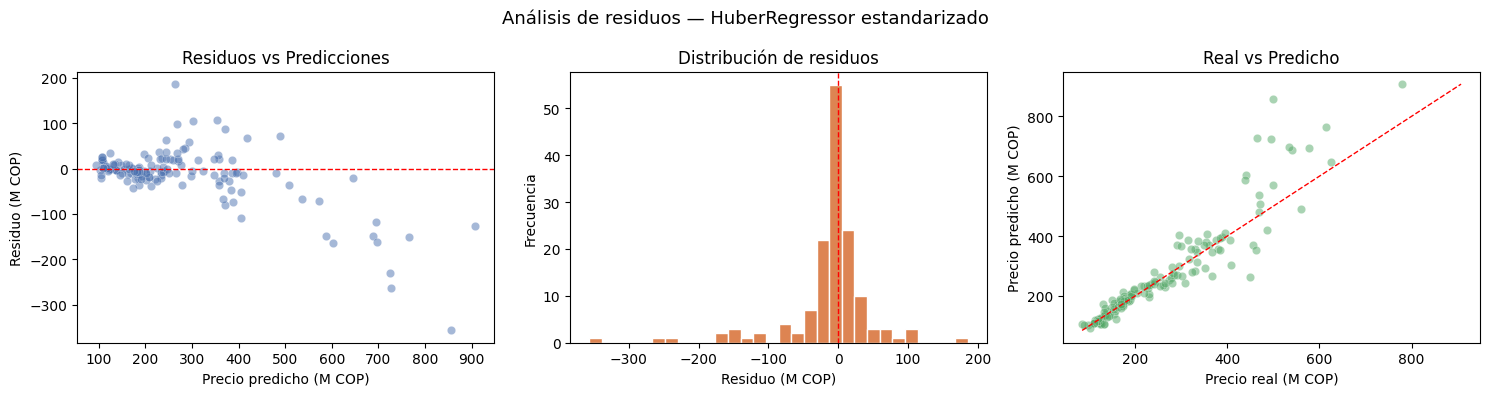

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuos vs predicciones
axes[0].scatter(y_pred_cop / 1e6, residuos / 1e6,
                alpha=0.5, color="#4C72B0", edgecolors="white", linewidths=0.3)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Precio predicho (M COP)")
axes[0].set_ylabel("Residuo (M COP)")
axes[0].set_title("Residuos vs Predicciones")

# 2. Histograma de residuos
axes[1].hist(residuos / 1e6, bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residuo (M COP)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de residuos")

# 3. Real vs Predicho
axes[2].scatter(y_val_cop / 1e6, y_pred_cop / 1e6,
                alpha=0.5, color="#55A868", edgecolors="white", linewidths=0.3)
lims = [min(y_val_cop.min(), y_pred_cop.min()) / 1e6,
        max(y_val_cop.max(), y_pred_cop.max()) / 1e6]
axes[2].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[2].set_xlabel("Precio real (M COP)")
axes[2].set_ylabel("Precio predicho (M COP)")
axes[2].set_title("Real vs Predicho")

plt.suptitle("Análisis de residuos — HuberRegressor estandarizado", fontsize=13)
plt.tight_layout()
plt.show()

###  Interpretación de los gráficos

- **Residuos vs. Predicciones** — Los residuos se concentran cerca de cero entre 100 M y 300 M COP. Por encima de 400 M aumenta la dispersión y predominan los residuos negativos; el modelo subestima inmuebles de alto valor.
- **Distribución de residuos** — Presenta un pico pronunciado en cero y una cola izquierda larga, consistente con la kurtosis de 9.48.
- **Real vs. Predicho** — Las predicciones siguen la diagonal hasta aproximadamente 400 M COP. Por encima de ese valor, el modelo subestima sistemáticamente.

### Conclusión

El modelo tiene un desempeño sólido en el rango **85 M–400 M COP**, que representa el 80 % del dataset. La degradación en propiedades de alto valor es esperada: solo hay 69 inmuebles de estrato 5–6 en los datos, lo que limita la capacidad del modelo para generalizar en ese segmento.

## 12. Variables más influyentes — modelo final

Se examinan los coeficientes del HuberRegressor estandarizado para identificar
qué variables tienen mayor impacto sobre el precio predicho. El signo del
coeficiente indica la dirección del efecto y su magnitud refleja la importancia
relativa de cada variable.

### 12.1 Extracción de coeficientes
Se extraen los coeficientes del modelo desde el pipeline y se ordenan
por valor absoluto de mayor a menor.

In [67]:
# Extraer el modelo y el scaler del pipeline
modelo_final = pipe_huber_std.named_steps["model"]
scaler_final  = pipe_huber_std.named_steps["scaler"]

# Nombres de columnas
feature_names = X_train_enc.columns.tolist()

# Coeficientes
coefs = pd.Series(
    modelo_final.coef_,
    index=feature_names
).sort_values(key=abs, ascending=False)

print("=== Top 15 variables más influyentes ===\n")
print(coefs.head(15).round(4).to_string())

=== Top 15 variables más influyentes ===

área                    0.1688
estrato                 0.1600
garajes                 0.0783
administración          0.0702
barrio_CIUDAD USME     -0.0533
baños                   0.0441
barrio_Otro             0.0336
barrio_SANTA BARBARA   -0.0302
barrio_EL PRADO         0.0291
barrio_CASTILLA         0.0269
barrio_EL PORVENIR     -0.0268
barrio_TINTAL SUR      -0.0260
elevadores              0.0243
antiguedad             -0.0230
barrio_LA URIBE         0.0214


### 12.2 Gráfico de variables más influyentes
Los coeficientes positivos (amarillo) indican variables que suben el precio
predicho; los negativos (azul) lo reducen.

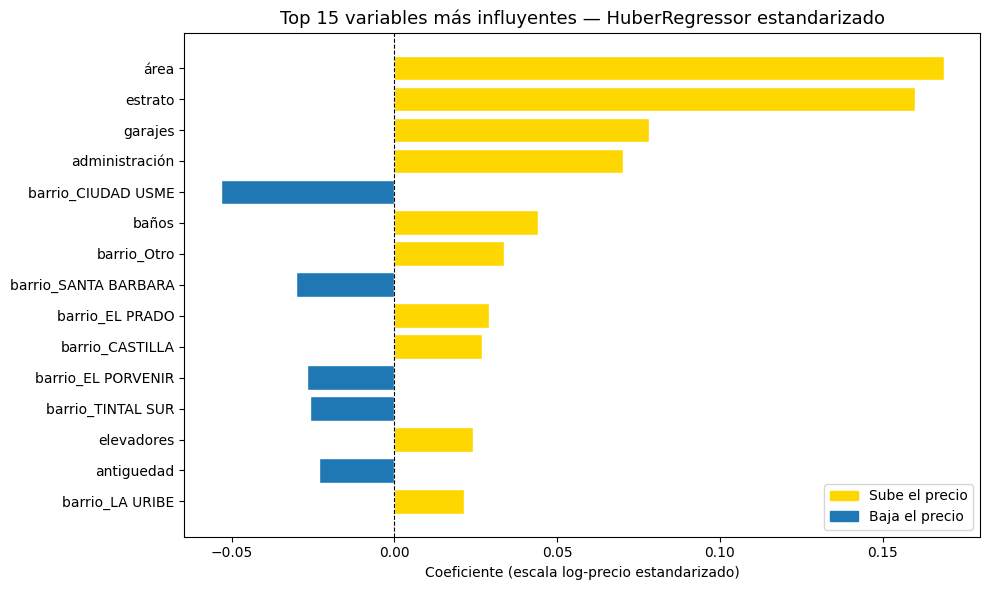

In [68]:
top_n = 15
top_coefs = coefs.head(top_n)

# Nuevos colores: amarillo para coeficientes positivos, azul para negativos
colores = ["#FFD700" if v > 0 else "#1F77B4" for v in top_coefs.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_coefs.index[::-1], top_coefs.values[::-1],
                color=colores[::-1], edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Top 15 variables más influyentes — HuberRegressor estandarizado",
          fontsize=13)
plt.xlabel("Coeficiente (escala log-precio estandarizado)")

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [Patch(color="#FFD700", label="Sube el precio"),
           Patch(color="#1F77B4", label="Baja el precio")]
plt.legend(handles=leyenda, loc="lower right")

plt.tight_layout()
plt.show()

###  Interpretación

**Variables numéricas:**
- **`área` (0.1688)** — la variable más influyente, consistente con la
  correlación de 0.61 detectada en la Sección 4.
- **`estrato` (0.1600)** — casi tan influyente como el área. Refleja
  ubicación, acceso a servicios y potencial de valorización. Variable
  exclusiva del sistema colombiano.
- **`garajes` (0.0783) y `administración` (0.0702)** — asociadas a
  inmuebles de mayor tamaño y conjuntos residenciales de mayor categoría.
- **`antigüedad` (-0.0230)** — a mayor antigüedad, menor precio.
  Signo negativo esperado.

**Variables de barrio:**
- **`barrio_CIUDAD USME` (-0.0533)** — coeficiente negativo más grande
  entre barrios, coherente con ser una de las zonas de menor valor en Bogotá.
- **`barrio_SANTA BARBARA` (-0.0302)** — coeficiente negativo inesperado
  en una zona premium. El modelo no captura su valor real por escasez de
  observaciones — el estrato ya absorbe parte de esa información.
- **`barrio_Otro` (0.0336)** — los barrios agrupados tienen en promedio
  precio ligeramente superior al barrio de referencia del modelo.

**Conclusión:** `área` y `estrato` dominan la predicción — exactamente lo
que cualquier agente inmobiliario bogotano confirmaría. El estrato, exclusivo
del contexto colombiano, aporta el segundo mayor poder predictivo del modelo.

## 13. Resumen Ejecutivo

Se consolidan los resultados del proyecto: métricas finales, hallazgos
principales, limitaciones identificadas y líneas de trabajo futuro.

### 13.1 Hallazgos principales

**1. Reducción significativa del error de predicción**

El modelo reduce el MAE de **105.2 M COP** (baseline) a **34.2 M COP**, una mejora del **67.5 %**. Esta precisión es útil para la tasación automatizada, el análisis de inversión y la detección de propiedades subvaloradas.

**2. `área` y `estrato` son las variables dominantes**

El estrato socioeconómico, variable exclusiva del sistema colombiano, es el segundo predictor más importante, superando al número de habitaciones y baños.

**3. Mejor desempeño en el segmento predominante**

El modelo funciona mejor entre **85 M y 400 M COP**, rango que representa el **80 %** del dataset. El error aumenta en propiedades de estrato 5–6 por la escasez de observaciones en ese segmento.

**4. Estandarización obligatoria para HuberRegressor**

Sin `StandardScaler`, el modelo presenta divergencia numérica (MAE > **400 billones de COP**). Este resultado queda documentado explícitamente como una lección metodológica del proyecto.

### 13.2 Limitaciones y trabajo futuro

- Incorporar más propiedades de **estrato 5–6** para mejorar el desempeño
  en el segmento premium.
- Agregar variables espaciales: distancia a estaciones de **TransMilenio**,
  parques e instituciones educativas.
- Evaluar modelos no lineales (**XGBoost**, **LightGBM**) para capturar
  relaciones más complejas en inmuebles de alto valor.
- Implementar el modelo como servicio de inferencia con **FastAPI** y
  desarrollar un panel interactivo con **Streamlit** para predicciones
  en tiempo real.

### 13.3 Firma del proyecto

**Autor:** Franklin Manuel Manjarres  
**Proyecto:** Análisis Predictivo de Precios de Vivienda — Bogotá, Colombia  
**Repositorio:** [github.com/franklinmanjarres](https://github.com/franklinmanjarres)  
**Stack:** Python · pandas · NumPy · scikit-learn · Matplotlib · Seaborn

In [76]:
#print(X_train_enc.columns.tolist())

modelo_huber.pkl — agrega esta celda al final del notebook y ejecútala:

In [74]:
import pickle
with open("modelo_huber.pkl", "wb") as f:
    pickle.dump(pipe_huber_std, f)
print("Modelo guardado correctamente")

Modelo guardado correctamente
